In [3]:
import copy

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [4]:
raw_data = pd.read_csv("data/data_raw.csv")
raw_data.head()

,Movie_Name,Release_Period,Whether_Remake,Whether_Franchise,Genre,New_Actor,New_Director,New_Music_Director,Lead_Star,Director,Music_Director,Number_of_Screens,Revenue(INR),Budget(INR)
0,Golden Boys,Normal,No,No,suspense,Yes,No,No,Jeet Goswami,Ravi Varma,Baba Jagirdar,5,5000000,85000
1,Kaccha Limboo,Holiday,No,No,drama,Yes,No,Yes,Karan Bhanushali,Sagar Ballary,Amardeep Nijjer,75,15000000,825000
2,Not A Love Story,Holiday,No,No,thriller,No,No,No,Mahie Gill,Ram Gopal Verma,Sandeep Chowta,525,75000000,56700000
3,Qaidi Band,Holiday,No,No,drama,Yes,No,No,Aadar Jain,Habib Faisal,Amit Trivedi,800,210000000,4500000
4,Chaatwali,Holiday,No,No,adult,Yes,Yes,Yes,Aadil Khan,Aadil Khan,Babloo Ustad,1,1000000,1075000


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1698 entries, 0 to 1697
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Movie_Name          1698 non-null   object
 1   Release_Period      1698 non-null   object
 2   Whether_Remake      1698 non-null   object
 3   Whether_Franchise   1698 non-null   object
 4   Genre               1698 non-null   object
 5   New_Actor           1698 non-null   object
 6   New_Director        1698 non-null   object
 7   New_Music_Director  1698 non-null   object
 8   Lead_Star           1698 non-null   object
 9   Director            1698 non-null   object
 10  Music_Director      1698 non-null   object
 11  Number_of_Screens   1698 non-null   int64 
 12  Revenue(INR)        1698 non-null   int64 
 13  Budget(INR)         1698 non-null   int64 
dtypes: int64(3), object(11)
memory usage: 185.8+ KB


In [6]:
raw_data.describe()

,Number_of_Screens,Revenue(INR),Budget(INR)
count,1698.000000,1.698000e+03,1.698000e+03
mean,553.831567,1.501674e+08,2.377287e+08
std,782.951839,2.434838e+08,6.134398e+08
min,1.000000,3.250000e+05,7.250000e+03
25%,30.000000,1.500000e+07,1.150000e+06
50%,200.000000,5.500000e+07,1.240000e+07
75%,800.000000,1.900000e+08,1.778325e+08
max,4600.000000,2.100000e+09,8.016120e+09


In [7]:
raw_data['Genre'].value_counts()

Genre
drama           639
comedy          284
thriller        212
love_story      133
action          127
rom__com         95
adult            78
horror           53
suspense         30
masala           16
mythological     14
fantasy          13
animation         3
documentary       1
Name: count, dtype: int64

In [8]:
raw_data['Music_Director'].value_counts()

Music_Director
Pritam                    92
Himesh Reshammiya         51
Sajid - Wajid             48
Anu Malik                 42
Shankar - Ehsaan - Loy    41
                          ..
Wayne Sharpe               1
Lalit Sen                  1
Gaurav Dayal               1
Tabun Sutradhar            1
Nazam Sheraz               1
Name: count, Length: 630, dtype: int64

In [9]:
prepared_data = raw_data.drop(columns=['Movie_Name'])

columns_to_label_encode = ['Release_Period', 'Whether_Remake', 'Whether_Franchise', 'New_Actor', 'New_Director', 'New_Music_Director', ]

label_encoder = LabelEncoder()
for column in columns_to_label_encode:
    prepared_data[column] = label_encoder.fit_transform(prepared_data[column])

prepared_data.head()

,Release_Period,Whether_Remake,Whether_Franchise,Genre,New_Actor,New_Director,New_Music_Director,Lead_Star,Director,Music_Director,Number_of_Screens,Revenue(INR),Budget(INR)
0,1,0,0,suspense,1,0,0,Jeet Goswami,Ravi Varma,Baba Jagirdar,5,5000000,85000
1,0,0,0,drama,1,0,1,Karan Bhanushali,Sagar Ballary,Amardeep Nijjer,75,15000000,825000
2,0,0,0,thriller,0,0,0,Mahie Gill,Ram Gopal Verma,Sandeep Chowta,525,75000000,56700000
3,0,0,0,drama,1,0,0,Aadar Jain,Habib Faisal,Amit Trivedi,800,210000000,4500000
4,0,0,0,adult,1,1,1,Aadil Khan,Aadil Khan,Babloo Ustad,1,1000000,1075000


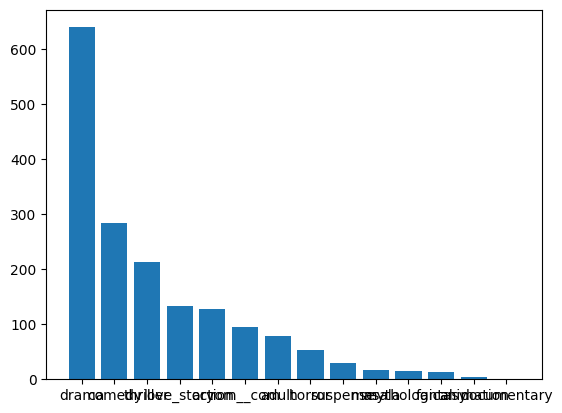

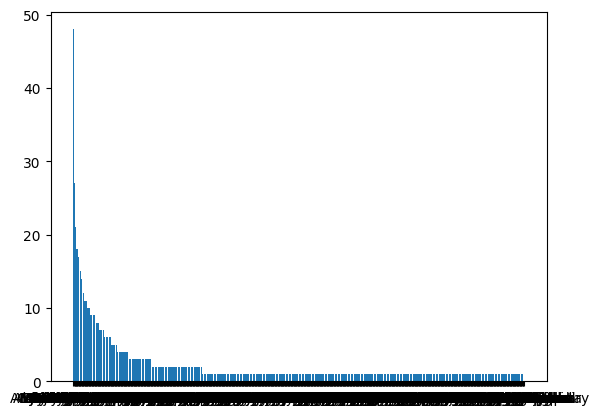

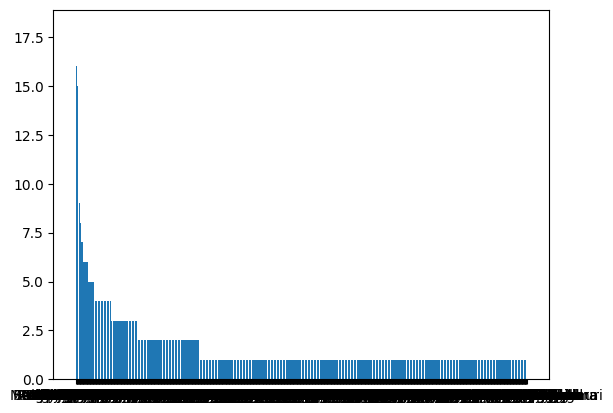

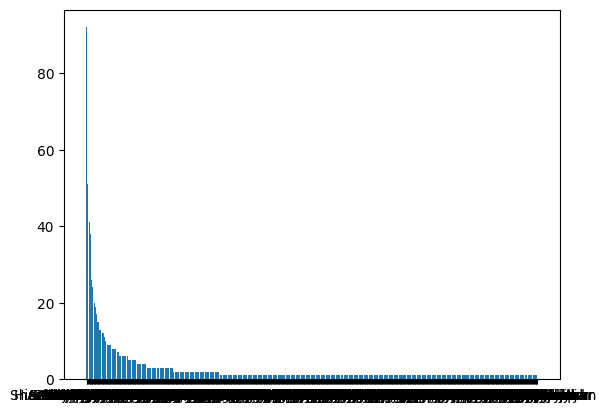

In [10]:
category_columns = ['Genre', 'Lead_Star', 'Director', 'Music_Director']

for column in category_columns:
    labels = prepared_data[column].value_counts().index
    heights = prepared_data[column].value_counts().to_numpy()
    plt.figure()
    plt.bar(labels, heights)
    plt.show()

In [11]:
genre_counts = prepared_data['Genre'].value_counts()
genres_to_group = [genre_counts.index[i] for i in range(genre_counts.shape[0]) if genre_counts.iloc[i] < 100]

encoded_data = copy.deepcopy(prepared_data)

encoded_data.loc[encoded_data.Genre.isin(genres_to_group), 'Genre'] = 'other'
genre_counts = encoded_data['Genre'].value_counts()
genre_counts

Genre
drama         639
other         303
comedy        284
thriller      212
love_story    133
action        127
Name: count, dtype: int64

In [12]:
lead_actor_counts = prepared_data['Lead_Star'].value_counts()
lead_actors_several_films = [lead_actor_counts.index[i] for i in range(lead_actor_counts.shape[0]) if lead_actor_counts.iloc[i] > 1]
lead_actors_one_film = [lead_actor_counts.index[i] for i in range(lead_actor_counts.shape[0]) if lead_actor_counts.iloc[i] == 1]

encoded_data.loc[encoded_data['Lead_Star'].isin(lead_actors_several_films), 'Lead_Star'] = 1
encoded_data.loc[encoded_data['Lead_Star'].isin(lead_actors_one_film), 'Lead_Star'] = 0
encoded_data['Lead_Star'].value_counts()

Lead_Star
1    1153
0     545
Name: count, dtype: int64

In [13]:
director_counts = prepared_data['Director'].value_counts()
directors_several_films = [director_counts.index[i] for i in range(director_counts.shape[0]) if director_counts.iloc[i] > 1]
directors_one_film = [director_counts.index[i] for i in range(director_counts.shape[0]) if director_counts.iloc[i] == 1]

encoded_data.loc[encoded_data['Director'].isin(directors_several_films), 'Director'] = 1
encoded_data.loc[encoded_data['Director'].isin(directors_one_film), 'Director'] = 0
encoded_data['Director'].value_counts()

Director
1    937
0    761
Name: count, dtype: int64

In [14]:
music_director_counts = prepared_data['Music_Director'].value_counts()
music_directors_several_films = [music_director_counts.index[i] for i in range(music_director_counts.shape[0]) if music_director_counts.iloc[i] > 2]
music_directors_one_film = [music_director_counts.index[i] for i in range(music_director_counts.shape[0]) if music_director_counts.iloc[i] <= 2]

encoded_data.loc[encoded_data['Music_Director'].isin(music_directors_several_films), 'Music_Director'] = 1
encoded_data.loc[encoded_data['Music_Director'].isin(music_directors_one_film), 'Music_Director'] = 0
encoded_data['Music_Director'].value_counts()

Music_Director
1    1124
0     574
Name: count, dtype: int64

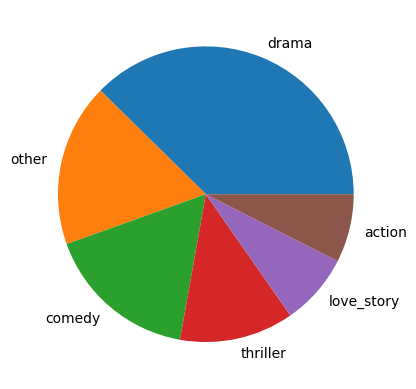

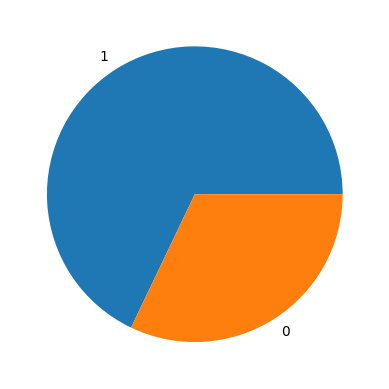

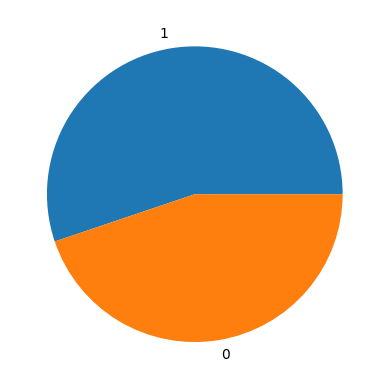

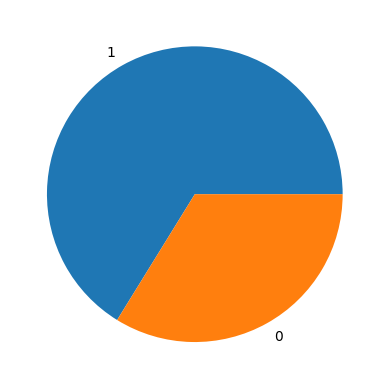

In [15]:
category_columns = ['Genre', 'Lead_Star', 'Director', 'Music_Director']

for column in category_columns:
    labels = encoded_data[column].value_counts().index
    heights = encoded_data[column].value_counts().to_numpy()
    plt.figure()
    plt.pie(x=heights, labels=labels)
    plt.show()

In [16]:
encoded_data.head()

,Release_Period,Whether_Remake,Whether_Franchise,Genre,New_Actor,New_Director,New_Music_Director,Lead_Star,Director,Music_Director,Number_of_Screens,Revenue(INR),Budget(INR)
0,1,0,0,other,1,0,0,1,1,1,5,5000000,85000
1,0,0,0,drama,1,0,1,0,1,0,75,15000000,825000
2,0,0,0,thriller,0,0,0,1,1,1,525,75000000,56700000
3,0,0,0,drama,1,0,0,0,1,1,800,210000000,4500000
4,0,0,0,other,1,1,1,0,0,0,1,1000000,1075000


In [17]:
encoded_data = pd.get_dummies(encoded_data, columns=['Genre'], dtype='int')
encoded_data.head()

,Release_Period,Whether_Remake,Whether_Franchise,New_Actor,New_Director,New_Music_Director,Lead_Star,Director,Music_Director,Number_of_Screens,Revenue(INR),Budget(INR),Genre_action,Genre_comedy,Genre_drama,Genre_love_story,Genre_other,Genre_thriller
0,1,0,0,1,0,0,1,1,1,5,5000000,85000,0,0,0,0,1,0
1,0,0,0,1,0,1,0,1,0,75,15000000,825000,0,0,1,0,0,0
2,0,0,0,0,0,0,1,1,1,525,75000000,56700000,0,0,0,0,0,1
3,0,0,0,1,0,0,0,1,1,800,210000000,4500000,0,0,1,0,0,0
4,0,0,0,1,1,1,0,0,0,1,1000000,1075000,0,0,0,0,1,0


<Axes: >

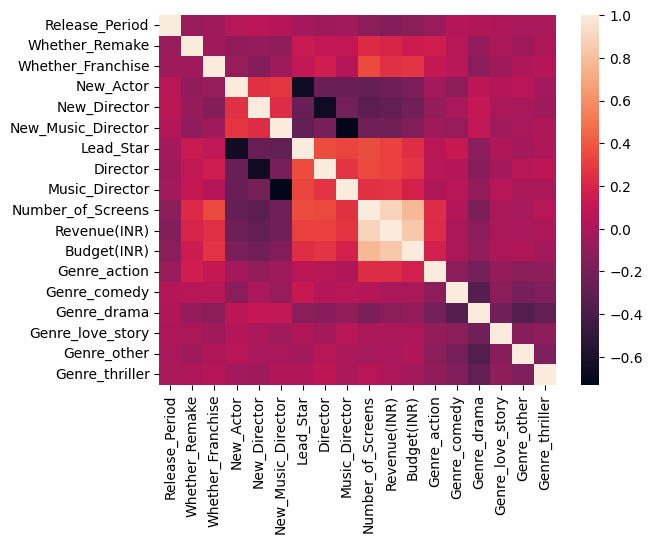

In [18]:
corr = encoded_data.corr()
sns.heatmap(corr, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

<Axes: >

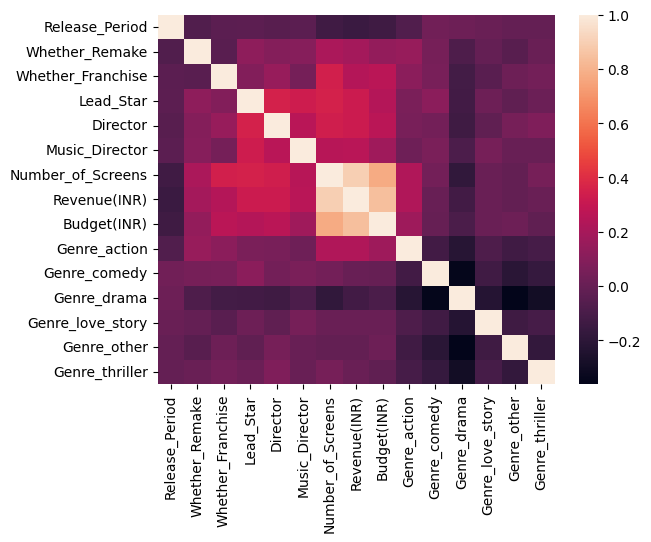

In [19]:
dropped_data = encoded_data.drop(columns=['New_Actor', 'New_Director', 'New_Music_Director'])

corr = dropped_data.corr()
sns.heatmap(corr, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

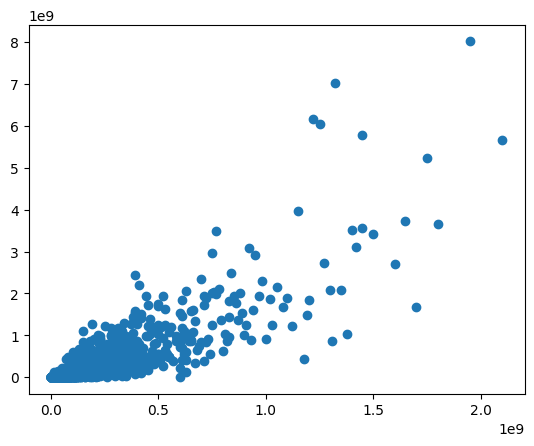

In [20]:
plt.scatter(dropped_data['Revenue(INR)'].to_numpy(), dropped_data['Budget(INR)'].to_numpy())
plt.show()

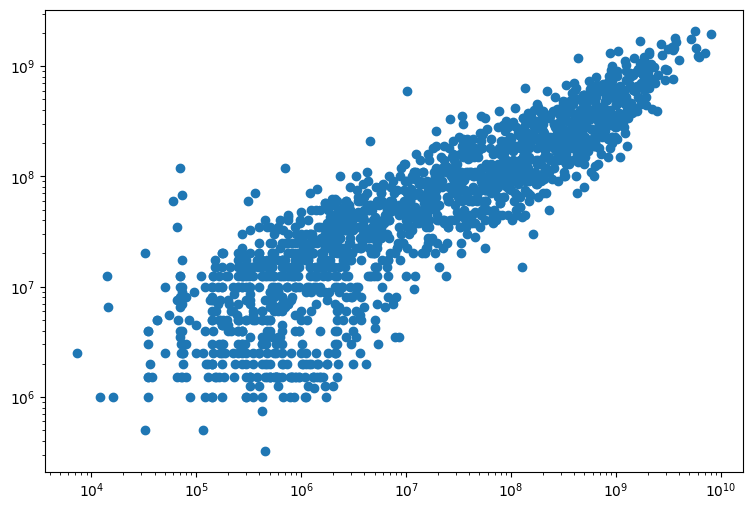

In [27]:
fig, ax = plt.subplots(figsize = (9, 6))
ax.scatter(y=dropped_data['Revenue(INR)'].to_numpy(), x=dropped_data['Budget(INR)'].to_numpy())

ax.set_yscale("log")
ax.set_xscale("log")

In [212]:
dropped_data.to_csv('data/data_preprocessed.csv', index=False)